In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
orders = pd.read_csv("orders.csv")
order_products = pd.read_csv("order_products__train.csv")

In [ ]:
orders.head()


,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1.0,2.0,8.0,NaN
1,2398795,1,prior,2.0,3.0,7.0,15.0
2,473747,1,prior,3.0,3.0,12.0,21.0
3,2254736,1,prior,4.0,4.0,7.0,29.0
4,431534,1,prior,5.0,4.0,15.0,28.0


In [ ]:
order_products.head()

,order_id,product_id,add_to_cart_order,reordered
0,1,49302,1,1
1,1,11109,2,1
2,1,10246,3,0
3,1,49683,4,0
4,1,43633,5,1


In [ ]:
orders.columns

Index(['order_id', 'user_id', 'eval_set', 'order_number', 'order_dow',
       'order_hour_of_day', 'days_since_prior_order'],
      dtype='object')

In [ ]:
order_products.columns

Index(['order_id', 'product_id', 'add_to_cart_order', 'reordered'], dtype='object')

In [ ]:
data = pd.merge(order_products, orders, on='order_id')

In [ ]:
data.head()

,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,1,49302,1,1,112108,train,4.0,4.0,10.0,9.0
1,1,11109,2,1,112108,train,4.0,4.0,10.0,9.0
2,1,10246,3,0,112108,train,4.0,4.0,10.0,9.0
3,1,49683,4,0,112108,train,4.0,4.0,10.0,9.0
4,1,43633,5,1,112108,train,4.0,4.0,10.0,9.0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 754558 entries, 0 to 754557
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                754558 non-null  int64  
 1   product_id              754558 non-null  int64  
 2   add_to_cart_order       754558 non-null  int64  
 3   reordered               754558 non-null  int64  
 4   user_id                 754558 non-null  int64  
 5   eval_set                754558 non-null  object 
 6   order_number            754558 non-null  float64
 7   order_dow               754558 non-null  float64
 8   order_hour_of_day       754558 non-null  float64
 9   days_since_prior_order  754558 non-null  float64
dtypes: float64(4), int64(5), object(1)
memory usage: 57.6+ MB


In [ ]:
data.describe()

,order_id,product_id,add_to_cart_order,reordered,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
count,7.545580e+05,754558.000000,754558.000000,754558.000000,754558.000000,754558.000000,754558.000000,754558.000000,754558.000000
mean,1.706924e+06,25561.952332,8.758134,0.600408,56209.768321,17.178767,2.713748,13.593722,17.012894
std,9.900233e+05,14121.925375,7.410844,0.489815,32373.591106,16.658157,2.174297,4.235567,10.423562
min,1.000000e+00,1.000000,1.000000,0.000000,1.000000,4.000000,0.000000,0.000000,0.000000
25%,8.444050e+05,13380.000000,3.000000,0.000000,28137.000000,6.000000,1.000000,10.000000,7.000000
50%,1.703367e+06,25330.000000,7.000000,1.000000,56423.000000,11.000000,3.000000,14.000000,15.000000
75%,2.566257e+06,37952.000000,12.000000,1.000000,84231.000000,21.000000,5.000000,17.000000,30.000000
max,3.421056e+06,49688.000000,77.000000,1.000000,112229.000000,100.000000,6.000000,23.000000,30.000000


In [ ]:
#datapreprocessing
data.isnull().sum()

,0
order_id,0
product_id,0
add_to_cart_order,0
reordered,0
user_id,0
eval_set,0
order_number,0
order_dow,0
order_hour_of_day,0
days_since_prior_order,0


In [ ]:
data.dtypes

,0
order_id,int64
product_id,int64
add_to_cart_order,int64
reordered,int64
user_id,int64
eval_set,object
order_number,float64
order_dow,float64
order_hour_of_day,float64
days_since_prior_order,float64


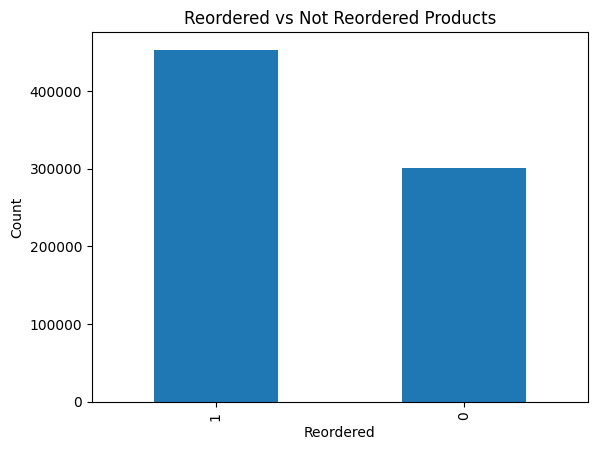

In [ ]:
data['reordered'].value_counts().plot(kind='bar')
plt.title("Reordered vs Not Reordered Products")
plt.xlabel("Reordered")
plt.ylabel("Count")
plt.show()

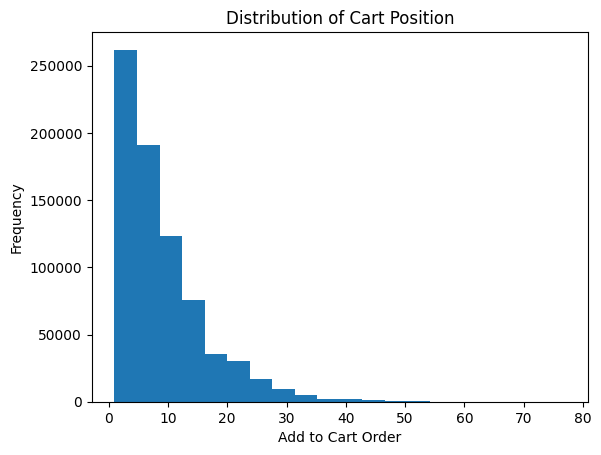

In [ ]:
plt.hist(data['add_to_cart_order'], bins=20)
plt.title("Distribution of Cart Position")
plt.xlabel("Add to Cart Order")
plt.ylabel("Frequency")
plt.show()
#This shows how early or late items are added to carts.

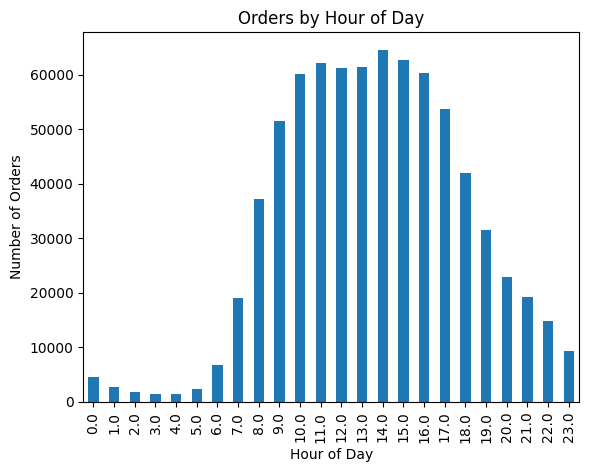

In [ ]:
data['order_hour_of_day'].value_counts().sort_index().plot(kind='bar')
plt.title("Orders by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Orders")
plt.show()
#This shows when people mostly shop.

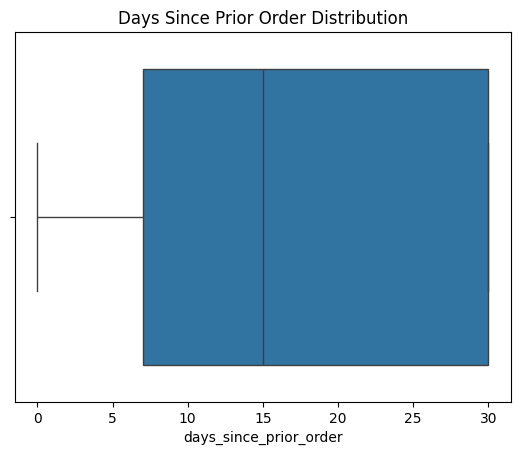

In [ ]:
sns.boxplot(x=data['days_since_prior_order'])
plt.title("Days Since Prior Order Distribution")
plt.show()
#Shows customer purchase frequency patterns

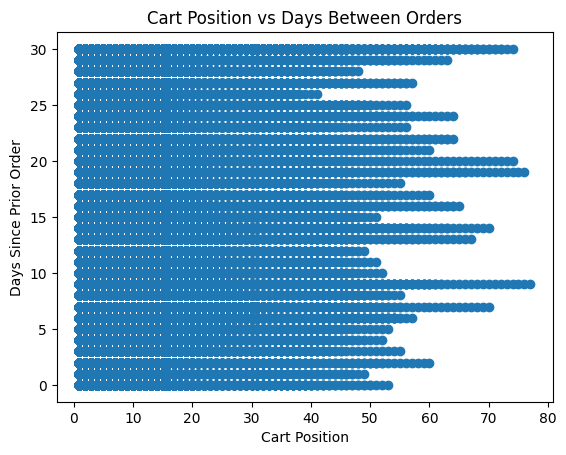

In [ ]:
plt.scatter(data['add_to_cart_order'], data['days_since_prior_order'])
plt.xlabel("Cart Position")
plt.ylabel("Days Since Prior Order")
plt.title("Cart Position vs Days Between Orders")
plt.show()

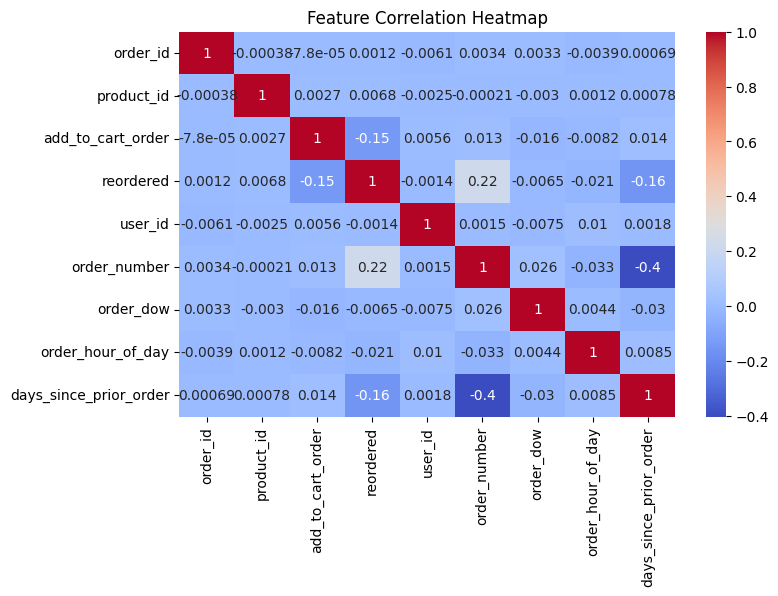

In [ ]:
plt.figure(figsize=(8,5))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:
#feature selection

X = data[['product_id','add_to_cart_order','order_hour_of_day','days_since_prior_order']]
y = data['reordered']


In [ ]:
X.head()

,product_id,add_to_cart_order,order_hour_of_day,days_since_prior_order
0,49302,1,10.0,9.0
1,11109,2,10.0,9.0
2,10246,3,10.0,9.0
3,49683,4,10.0,9.0
4,43633,5,10.0,9.0


In [ ]:
y.head()

,reordered
0,1
1,1
2,0
3,0
4,1


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
print(X_train.shape)
print(X_test.shape)

(603646, 4)
(150912, 4)


In [ ]:
#feature scalin
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
#centers data around mean = 0,scales variance to 1, This prevents large values like product_id from dominating the model.

In [ ]:
X_train_scaled[:5]

array([[-0.59841425, -0.6423775 , -0.37567335,  0.38255061],
       [ 0.38086782, -0.91200278, -1.55590251,  1.24605029],
       [ 0.25288903,  2.86275115, -0.61171918, -0.38500466],
       [ 0.76416677,  0.0316857 ,  1.74873913, -1.63228198],
       [-0.0509455 , -0.37275222,  1.5126933 , -1.05661553]])

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.6258481764206955


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.58      0.24      0.34     60355
           1       0.63      0.89      0.74     90557

    accuracy                           0.63    150912
   macro avg       0.61      0.56      0.54    150912
weighted avg       0.61      0.63      0.58    150912



In [ ]:
confusion_matrix(y_test, y_pred)

array([[14234, 46121],
       [10343, 80214]])

In [ ]:
from sklearn.linear_model import LinearRegression

lin_model = LinearRegression()

lin_model.fit(X_train_scaled, y_train)

y_pred_lr = lin_model.predict(X_test_scaled)

print("Linear Regression Predictions (first 10):")
print(y_pred_lr[:10])

Linear Regression Predictions (first 10):
[0.4149229  0.42284671 0.70917425 0.74104758 0.57283547 0.70401181
 0.42096082 0.51906897 0.75643188 0.72060952]


In [ ]:
import numpy as np
y_pred_lr_binary = np.where(y_pred_lr > 0.5, 1, 0)

from sklearn.metrics import accuracy_score
print("Linear Regression Accuracy:", accuracy_score(y_test, y_pred_lr_binary))

Linear Regression Accuracy: 0.6257156488549618


In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

from sklearn.metrics import accuracy_score
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.5631825169635284


In [ ]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()

nb_model.fit(X_train_scaled, y_train)

y_pred_nb = nb_model.predict(X_test_scaled)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.6191820398642918


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

KNN Accuracy: 0.5831610474978796


In [ ]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(max_iter=2000)

svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))